# IHDP-100

This notebook assesses whether TFM-based base learners improve causal machine learning performance within meta-learning frameworks, compared to conventional baseline methods.

**Dataset**: IHDP (Infant Health and Development Program), a semi-synthetic benchmark derived from a real RCT with simulated potential outcomes.
- 100 replications from the NPCI benchmark (`ihdp_npci_1-100.train.npz` / `.test.npz`)
- 672 train / 75 test samples per replication, 25 covariates
- Outcome = simulated continuous response; true ITE available from `mu0`/`mu1`

**Evaluation protocol**:
- Pre-split train/test sets per replication (fixed NPCI splits)
- All models trained on training set only, evaluated on held-out test set
- R-learner (NonParamDML) and DR-learner (DRLearner) use 5-fold cross-fitting within the training data for nuisance estimation
- LightGBM hyperparameters tuned once per replication via RandomizedSearchCV (30 iterations, 3-fold CV)

**Metrics** (all computed on the test set per replication):
- **PEHE**: Precision in Estimating Heterogeneous Effects — RMSE between predicted and true ITE. Lower is better.
- **ATE Error**: Absolute difference between mean predicted ITE and mean true ITE. Lower is better.

**Models**:
- Meta-learners: S, T, X, R (NonParamDML, cv=5), DR (DRLearner, cv=5)
- Base models: LinearRegression, LightGBM (tuned), TabPFN, TabICL
- Standalone: CausalForestDML (LightGBM nuisance), CausalPFN

## 1. Setup and Imports

In [23]:
# ── IMPORTS ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, KFold
from tabpfn import TabPFNRegressor, TabPFNClassifier
from tabicl import TabICLRegressor, TabICLClassifier
import matplotlib.pyplot as plt
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML, CausalForestDML
from econml.dr import DRLearner
from sklearn.metrics import mean_squared_error
import warnings
import torch
import tabpfn
from causalpfn import CATEEstimator
from collections import defaultdict
import time


# Ensure we use the latest version of TabPFN.
# We use TabPFN 2.6, which corresponds to GitHub 7.x versions
print(tabpfn.__version__)


# ── DEVICE DETECTION ─────────────────────────────────────────────────────────
# Detect available device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using device: {device}")

# CausalPFN device: CUDA or CPU
causalpfn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"CausalPFN device: {causalpfn_device}")

# TabICL device
tabicl_device = "cpu" if device == "mps" else device
print(f"TabICL device: {tabicl_device}")


# ── EXTRA ─────────────────────────────────────────────────────────
np.random.seed(42) # Set random seed for reproducibility
# Suppress warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*feature names.*")

import os
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning" # Ignore warnings
os.environ["TABPFN_NO_TELEMETRY_PROMPT"] = "1" # Skip TabPFN prompt

# To prevent crashes. Avoid CPU over-subscription.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

7.1.1
Using device: mps
CausalPFN device: cpu
TabICL device: cpu


In [24]:
# ── Import TabPFN 2.5 alongside 2.6 ────────────────────────────────────────
import subprocess, sys as _sys

TABPFN25_DIR = "./tabpfn_v25_install"
os.makedirs(TABPFN25_DIR, exist_ok=True)

# Install tabpfn 2.5 to isolated directory if not already present
_tabpfn25_installed = any("tabpfn" in d for d in os.listdir(TABPFN25_DIR))
if not _tabpfn25_installed:
    print("Installing TabPFN 2.5 to isolated directory...")
    subprocess.check_call([
        _sys.executable, "-m", "pip", "install", "tabpfn==6.4.1",
        f"--target={TABPFN25_DIR}", "--quiet", "--no-deps"
    ])
    print("Done.")

# Save current tabpfn 2.6 module references
_tabpfn26_mods = {k: v for k, v in _sys.modules.items()
                  if k == "tabpfn" or k.startswith("tabpfn.")}

# Temporarily inject 2.5 path and load its classes
_sys.path.insert(0, TABPFN25_DIR)
for _k in [k for k in list(_sys.modules) if k == "tabpfn" or k.startswith("tabpfn.")]:
    del _sys.modules[_k]

import tabpfn as _tabpfn25
TabPFNRegressor25 = _tabpfn25.TabPFNRegressor
TabPFNClassifier25 = _tabpfn25.TabPFNClassifier
TABPFN25_VERSION = _tabpfn25.__version__

# Restore tabpfn 2.6
_sys.path.remove(TABPFN25_DIR)
for _k in [k for k in list(_sys.modules) if k == "tabpfn" or k.startswith("tabpfn.")]:
    del _sys.modules[_k]
_sys.modules.update(_tabpfn26_mods)

print(f"TabPFN 2.5 version: {TABPFN25_VERSION}")
print(f"TabPFN 2.6 version: {tabpfn.__version__}")

TabPFN 2.5 version: 6.4.1
TabPFN 2.6 version: 7.1.1


## 2. Define Models, Tuning, and Metrics

We define LightGBM hyperparameter tuning functions (using `RandomizedSearchCV`) and evaluation metrics. LightGBM is tuned **once per replication** — the best hyperparameters are then reused across all meta-learners for that replication.

In [25]:
# ── TUNING ─────────────────────────────────────────────────────────
# LightGBM hyperparameter search space
LGBM_GRID = {
    'num_leaves':        [15, 31, 63],
    'min_child_samples': [20, 50, 100],
    'n_estimators':      [200, 500, 1000],
}

N_ITER = 30    # RandomizedSearchCV draws
N_EST       = 1000  # base tree count (overridden by grid)
NUISANCE_CV = 5    # K-fold cross-fitting for R- and DR-learner nuisance models

# LightGBM Tuning
def tune_lgbm(X, y, classifier = False, stratify = None, n_iter = N_ITER, seed = 42):
    """Tune LGBM via RandomizedSearchCV. Returns best_params_ dict.

    - classifier = False  → LGBMRegressor, scored by neg_MSE
    - classifier = True   → LGBMClassifier, scored by neg_log_loss
    - stratify          → use StratifiedKFold on this variable (regression only);
                          if None, falls back to KFold with adaptive n_splits
    """
    X = np.asarray(X)

    if classifier:
        # Propensity Model (classification)
        base    = LGBMClassifier(n_estimators = N_EST, random_state = seed, verbose = -1)
        scoring = 'neg_log_loss'
        cv      = list(StratifiedKFold(3, shuffle = True, random_state = seed).split(X, y))
    else:
        # Outcome Model (regression): S-, R-, and DR-learner
        base    = LGBMRegressor(n_estimators = N_EST, random_state = seed, verbose = -1)
        scoring = 'neg_mean_squared_error'
        if stratify is not None:
            cv  = list(StratifiedKFold(3, shuffle = True, random_state = seed).split(X, stratify))
        else:
            # Single Treatment Arm: T- and X-learner
            n_splits = min(3, max(2, len(y) // 20))
            cv  = list(KFold(n_splits, shuffle = True, random_state = seed).split(X))

    search = RandomizedSearchCV(
        base, LGBM_GRID, n_iter = n_iter, scoring = scoring,
        cv = cv, n_jobs = -1, random_state = seed,
    )

    search.fit(X, y)
    return search.best_params_

# Pseudo-Outcome Tuning: X-, R-, and DR-learner final-stage models
def make_lgbm_final(seed = 42):
    """LGBM wrapped in RandomizedSearchCV for final-stage tuning on pseudo-outcomes."""
    return RandomizedSearchCV(
        LGBMRegressor(n_estimators=N_EST, random_state=seed, verbose=-1),
        LGBM_GRID, n_iter=N_ITER, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=seed,
    )



# ── Evaluation Metric functions ─────────────────────────────────────────────────────────
def calculate_pehe(predicted_ite, true_ite):
    return np.sqrt(mean_squared_error(true_ite, predicted_ite))

def calculate_ate_error(predicted_ite, true_ite):
    return np.abs(predicted_ite.mean() - true_ite.mean())


## 3. Data Loading (IHDP 1-100)

We load 100 realizations of the IHDP dataset from local `.npz` files and store them for evaluation.

In [26]:
# ── Data Loading ─────────────────────────────────────────────────────────
# Store results for all runs
# Structure: results[meta_learner][base_model][metric] = list of values
all_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Load IHDP data from local npz files (100 replications)
train_data = np.load('ihdp_npci_1-100.train.npz')
test_data = np.load('ihdp_npci_1-100.test.npz')

n_datasets = 100
processed_datasets = []
feature_names = [f"x{j}" for j in range(25)]

print(f"Loading {n_datasets} replications from local IHDP files...")

# Process Datasets
for i in range(n_datasets):
    X_train = pd.DataFrame(train_data['x'][:, :, i], columns=feature_names)
    T_train, Y_train, mu0_train, mu1_train = (train_data[k][:, i] for k in ('t', 'yf', 'mu0', 'mu1'))

    X_test = pd.DataFrame(test_data['x'][:, :, i], columns=feature_names)
    T_test, Y_test, mu0_test, mu1_test = (test_data[k][:, i] for k in ('t', 'yf', 'mu0', 'mu1'))

    true_ITE_test = mu1_test - mu0_test

    processed_datasets.append({
        'id': i + 1,
        'X_train': X_train,
        'X_test': X_test,
        'T_train': T_train,
        'T_test': T_test,
        'Y_train': Y_train,
        'Y_test': Y_test,
        'true_ITE_test': true_ITE_test
    })


# ── Data Summary ─────────────────────────────────────────────────────────
rep = processed_datasets[0]
X_tr, T_tr, Y_tr = rep['X_train'], rep['T_train'], rep['Y_train']
X_te, T_te, Y_te = rep['X_test'],  rep['T_test'],  rep['Y_test']

n_train, n_test = len(T_tr), len(T_te)
n_total    = n_train + n_test
n_treated  = int(T_tr.sum()) + int(T_te.sum())
n_control  = n_total - n_treated
ate_naive  = Y_tr[T_tr == 1].mean() - Y_tr[T_tr == 0].mean()
true_ate   = rep['true_ITE_test'].mean()

Y_all_rep  = np.concatenate([Y_tr, Y_te])

print("=" * 55)
print("IHDP Dataset Summary (replication 1)")
print("=" * 55)
print(f"  Replications   : {n_datasets}")
print(f"  Train samples  : {n_train}  |  Test samples: {n_test}")
print(f"  Total (rep 1)  : {n_total}")
print(f"  Treated        : {n_treated}  ({100*n_treated/n_total:.1f}%)")
print(f"  Control        : {n_control}  ({100*n_control/n_total:.1f}%)")
print(f"  Features       : {X_tr.shape[1]}")
print(f"  Outcome (Y)    : range [{Y_all_rep.min():.2f}, {Y_all_rep.max():.2f}]")
print(f"                   mean  {Y_all_rep.mean():.2f}  (std {Y_all_rep.std():.2f})")
print(f"  ATE naive      : {ate_naive:+.4f}  (treated mean - control mean, train)")
print(f"  True ATE       : {true_ate:+.4f}  (mean true ITE on test set)")
print()
print("Outcome by treatment arm (train, rep 1):")
print(f"  Treated  mean Y: {Y_tr[T_tr==1].mean():.4f}  (std {Y_tr[T_tr==1].std():.4f})")
print(f"  Control  mean Y: {Y_tr[T_tr==0].mean():.4f}  (std {Y_tr[T_tr==0].std():.4f})")

print(f"\nLoaded {len(processed_datasets)} replications.")
print(f"Train size: {X_tr.shape[0]}, Test size: {X_te.shape[0]}, Features: {X_tr.shape[1]}")

Loading 100 replications from local IHDP files...
IHDP Dataset Summary (replication 1)
  Replications   : 100
  Train samples  : 672  |  Test samples: 75
  Total (rep 1)  : 747
  Treated        : 139  (18.6%)
  Control        : 608  (81.4%)
  Features       : 25
  Outcome (Y)    : range [-1.54, 11.27]
                   mean  3.16  (std 2.18)
  ATE naive      : +4.0047  (treated mean - control mean, train)
  True ATE       : +4.0563  (mean true ITE on test set)

Outcome by treatment arm (train, rep 1):
  Treated  mean Y: 6.4408  (std 1.1264)
  Control  mean Y: 2.4361  (std 1.6095)

Loaded 100 replications.
Train size: 672, Test size: 75, Features: 25


## 4. Unified Meta-Learner Evaluation

We evaluate all five meta-learners (S, T, X, R, DR) in a single loop over the 100 IHDP replications. For each replication, we tune LightGBM once for the outcome model (regressor) and once for the propensity model (classifier), then reuse those tuned models across all meta-learners. This avoids redundant tuning and ensures consistency.

In [27]:
# ── Evaluation Prep ─────────────────────────────────────────────────────────
print("Evaluating all meta-learners across 100 IHDP replications...\n")

for dataset in processed_datasets:
    i = dataset['id']
    n = len(processed_datasets)
    print(f"\n{'='*70}")
    print(f" Dataset {i}/{n}")
    print(f"{'='*70}")

    X_train, X_test = dataset['X_train'], dataset['X_test']
    T_train         = dataset['T_train']
    Y_train         = dataset['Y_train']
    true_ITE_test   = dataset['true_ITE_test']


    # ── Arm splits (needed for T- and X-learner tuning) ──────────────────────
    ctrl = T_train == 0
    trt  = T_train == 1
    X_ctrl, Y_ctrl = X_train[ctrl], Y_train[ctrl]
    X_trt,  Y_trt  = X_train[trt],  Y_train[trt]


    # ── LightGBM hyperparameter tuning ───────────────────────────────────────
    t0 = time.time()
    X_with_T        = np.column_stack([X_train, T_train])
    params_s        = tune_lgbm(X_with_T, Y_train, stratify = T_train)  # S-learner outcome (X+T features)
    params_outcome  = tune_lgbm(X_train,  Y_train, stratify = T_train)  # outcome nuisance (R/DR)
    params_prop     = tune_lgbm(X_train,  T_train, classifier = True)   # propensity model
    params_ctrl     = tune_lgbm(X_ctrl,   Y_ctrl)                       # T/X control arm outcome
    params_trt      = tune_lgbm(X_trt,    Y_trt)                        # T/X treated arm outcome
    print(f"  LightGBM tuning: {time.time() - t0:.1f}s")


    

    # ── Model configs ────────────────────────────────────────────────────────
    # Local shorthands to avoid repeating constructor args across 4 models × 11 roles
    def _lgbm_r(params, seed = 42): return LGBMRegressor(random_state=seed, verbose=-1, **params)
    def _lgbm_c(params, seed = 42): return LGBMClassifier(random_state=seed, verbose=-1, **params)
    def _tabpfn_r():                return TabPFNRegressor(device=device)
    def _tabpfn_c():                return TabPFNClassifier(device=device)
    def _tabicl_r(seed = 42):       return TabICLRegressor(device=tabicl_device, random_state=seed, verbose=False)
    def _tabicl_c(seed = 42):       return TabICLClassifier(device=tabicl_device, random_state = seed, verbose=False)
    def _tabpfn25_r():              return TabPFNRegressor25(device=device)
    def _tabpfn25_c():              return TabPFNClassifier25(device=device)

    base_model_configs = {
        'LinearRegression': {
            's_model':       LinearRegression(),
            't_models':      (LinearRegression(), LinearRegression()),
            'x_models':      (LinearRegression(), LinearRegression()),
            'x_cate':        (LinearRegression(), LinearRegression()),
            'x_propensity':  LogisticRegression(max_iter=1000, random_state=42),
            'r_model_y':     LinearRegression(),
            'r_model_t':     LogisticRegression(max_iter=1000, random_state=42),
            'r_model_final': LinearRegression(),
            'dr_regression': LinearRegression(),
            'dr_propensity': LogisticRegression(max_iter=1000, random_state=42),
            'dr_final':      LinearRegression(),
        },
        'LightGBM': {
            's_model':       _lgbm_r(params_s),
            't_models':      (_lgbm_r(params_ctrl, 42), _lgbm_r(params_trt, 43)),
            'x_models':      (_lgbm_r(params_ctrl, 42), _lgbm_r(params_trt, 43)),
            'x_cate':        (make_lgbm_final(46), make_lgbm_final(47)),
            'x_propensity':  _lgbm_c(params_prop, 44),
            'r_model_y':     _lgbm_r(params_outcome, 42),
            'r_model_t':    _lgbm_c(params_prop, 43), min_propensity=0.05, max_propensity=0.95),
            'r_model_final': make_lgbm_final(44),
            'dr_regression': _lgbm_r(params_outcome, 42),
            'dr_propensity': _lgbm_c(params_prop, 44),
            'dr_final':      make_lgbm_final(45),
        },
        'TabPFN_v25': {
            's_model':       _tabpfn25_r(),
            't_models':      (_tabpfn25_r(), _tabpfn25_r()),
            'x_models':      (_tabpfn25_r(), _tabpfn25_r()),
            'x_cate':        (_tabpfn25_r(), _tabpfn25_r()),
            'x_propensity':  _tabpfn25_c(),
            'r_model_y':     _tabpfn25_r(),
            'r_model_t':     ClippedClassifier(_tabpfn25_c(), min_propensity=0.05, max_propensity=0.95),
            'r_model_final': make_lgbm_final(44),
            'dr_regression': _tabpfn25_r(),
            'dr_propensity': _tabpfn25_c(),
            'dr_final':      _tabpfn25_r(),
        },
        'TabPFN': {
            's_model':       _tabpfn_r(),
            't_models':      (_tabpfn_r(), _tabpfn_r()),
            'x_models':      (_tabpfn_r(), _tabpfn_r()),
            'x_cate':        (_tabpfn_r(), _tabpfn_r()),
            'x_propensity':  _tabpfn_c(),
            'r_model_y':     _tabpfn_r(),
            'r_model_t':     ClippedClassifier(_tabpfn_c(), min_propensity=0.05, max_propensity=0.95),
            'r_model_final': make_lgbm_final(44),  # TabPFN not suited for residual-on-residual
            'dr_regression': _tabpfn_r(),
            'dr_propensity': _tabpfn_c(),
            'dr_final':      _tabpfn_r(),
        },
        'TabICL': {
            's_model':       _tabicl_r(),
            't_models':      (_tabicl_r(42), _tabicl_r(43)),
            'x_models':      (_tabicl_r(42), _tabicl_r(43)),
            'x_cate':        (_tabicl_r(44), _tabicl_r(45)),
            'x_propensity':  _tabicl_c(),
            'r_model_y':     _tabicl_r(),
            'r_model_t':     ClippedClassifier(_tabicl_c(), min_propensity=0.05, max_propensity=0.95),
            'r_model_final': make_lgbm_final(44),  # TabICL not suited for residual-on-residual
            'dr_regression': _tabicl_r(),
            'dr_propensity': _tabicl_c(),
            'dr_final':      _tabicl_r(),
        },
    }

    # ── Evaluation ─────────────────────────────────────────────────────────
    for name, cfg in base_model_configs.items():
        
        # ── S-Learner ─────────────────────────────────────────────────────────
        t0 = time.time()
        s_learner = SLearner(overall_model = cfg['s_model'])
        s_learner.fit(Y_train, T_train, X = X_train)
        te = s_learner.effect(X_test)
        
        all_results['S'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['S'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))
        print(f"  S-learner  + {name:20s}: {time.time() - t0:.1f}s")


        # ── T-Learner ─────────────────────────────────────────────────────────
        t0 = time.time()
        t_learner = TLearner(models = cfg['t_models'])
        t_learner.fit(Y_train, T_train, X = X_train)
        te = t_learner.effect(X_test)

        all_results['T'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['T'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))
        print(f"  T-learner  + {name:20s}: {time.time() - t0:.1f}s")


        # ── X-Learner ─────────────────────────────────────────────────────────
        t0 = time.time()
        x_learner = XLearner(models = cfg['x_models'], cate_models = cfg['x_cate'], propensity_model = cfg['x_propensity'])
        x_learner.fit(Y_train, T_train, X = X_train)
        te = x_learner.effect(X_test)

        all_results['X'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['X'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))
        print(f"  X-learner  + {name:20s}: {time.time() - t0:.1f}s")


        # ── R-learner (NonParamDML) ────────────────────────────────────────────
        t0 = time.time()
        r_learner = NonParamDML(
            model_y = cfg['r_model_y'], model_t = cfg['r_model_t'],
            model_final = cfg['r_model_final'], discrete_treatment = True, cv = NUISANCE_CV
        )
        r_learner.fit(Y_train, T_train, X = X_train)
        te = r_learner.effect(X_test)

        all_results['R'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['R'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))
        print(f"  R-learner  + {name:20s}: {time.time() - t0:.1f}s")


        # ── DR-learner ────────────────────────────────────────────
        t0 = time.time()
        dr_learner = DRLearner(
            model_regression = cfg['dr_regression'],
            model_propensity = cfg['dr_propensity'],
            model_final = cfg['dr_final'],
            min_propensity = 0.05,  # prevents extreme IPW weights
            cv = NUISANCE_CV
        )
        dr_learner.fit(Y_train, T_train, X=X_train)
        te = dr_learner.effect(X_test)
        
        all_results['DR'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['DR'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))
        print(f"  DR-learner + {name:20s}: {time.time() - t0:.1f}s")


    # ── Causal Forest (CausalForestDML) ───────────────────────────────────────
    try:
        t0 = time.time()
        cf = CausalForestDML(
            model_y = LGBMRegressor(random_state=42, verbose=-1, **params_outcome),
            model_t = LGBMClassifier(random_state=43, verbose=-1, **params_prop),
            discrete_treatment = True,
            n_estimators = 200,
            min_samples_leaf = 5,
            random_state = 42,
        )
        cf.tune(Y_train, T_train, X=X_train)
        cf.fit(Y_train, T_train, X=X_train)
        te = cf.effect(X_test)

        all_results['CF']['CausalForest']['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['CF']['CausalForest']['ate_error'].append(calculate_ate_error(te, true_ITE_test))
        print(f"  CF         + {'CausalForest':20s}: {time.time() - t0:.1f}s")

    except Exception as e:
        print(f"\nCausalForest error on dataset {i}: {e}")


    # ── CausalPFN ───────────────────────────────────────
    try:
        print(f"  [CausalPFN]...", end=" ", flush=True)
        _t0 = time.time()
        cpfn = CATEEstimator(device = causalpfn_device, verbose = False)

        X_cpfn_train = np.asarray(X_train, dtype=np.float32)
        T_cpfn_train = np.asarray(T_train, dtype=np.float32).ravel()
        Y_cpfn_train = np.asarray(Y_train, dtype=np.float32).ravel()
        X_cpfn_test = np.asarray(X_test, dtype=np.float32)


        cpfn.fit(X_cpfn_train, T_cpfn_train, Y_cpfn_train)
        te = cpfn.estimate_cate(X_cpfn_test)

        if "torch" in str(type(te)):
            te = te.detach().cpu().numpy()

        te = np.asarray(te, dtype=np.float32).reshape(-1)

        all_results["CausalPFN"]["CausalPFN"]["pehe"].append(calculate_pehe(te, true_ITE_test))
        all_results["CausalPFN"]["CausalPFN"]["ate_error"].append(calculate_ate_error(te, true_ITE_test))
        print(f"done. ({time.time() - _t0:.1f}s)")
    except Exception as exc:
        print(f"ERROR\n  CausalPFN error on dataset {i}: {exc}")

print("\nAll meta-learner evaluations complete.")


Evaluating all meta-learners across 100 IHDP replications...


 Dataset 1/100


analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full


  LightGBM tuning: 206.9s
  S-learner  + LinearRegression    : 0.0s
  T-learner  + LinearRegression    : 0.0s
  X-learner  + LinearRegression    : 0.0s
  R-learner  + LinearRegression    : 0.0s
  DR-learner + LinearRegression    : 0.0s
  S-learner  + LightGBM            : 0.3s
  T-learner  + LightGBM            : 0.6s
  X-learner  + LightGBM            : 51.1s
  R-learner  + LightGBM            : 54.7s
  DR-learner + LightGBM            : 53.2s
  S-learner  + TabPFN_v25          : 6.2s
  T-learner  + TabPFN_v25          : 5.6s
  X-learner  + TabPFN_v25          : 24.2s
  R-learner  + TabPFN_v25          : 111.1s
  DR-learner + TabPFN_v25          : 120.3s
  S-learner  + TabPFN              : 7.9s
  T-learner  + TabPFN              : 7.7s
  X-learner  + TabPFN              : 25.7s
  R-learner  + TabPFN              : 117.1s
  DR-learner + TabPFN              : 129.1s
  S-learner  + TabICL              : 9.8s
  T-learner  + TabICL              : 9.7s
  X-learner  + TabICL              : 

analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full


  LightGBM tuning: 205.6s
  S-learner  + LinearRegression    : 0.0s
  T-learner  + LinearRegression    : 0.0s
  X-learner  + LinearRegression    : 0.0s
  R-learner  + LinearRegression    : 0.0s
  DR-learner + LinearRegression    : 0.0s
  S-learner  + LightGBM            : 0.3s
  T-learner  + LightGBM            : 0.3s
  X-learner  + LightGBM            : 49.5s
  R-learner  + LightGBM            : 54.1s
  DR-learner + LightGBM            : 53.4s
  S-learner  + TabPFN_v25          : 6.2s
  T-learner  + TabPFN_v25          : 5.5s
  X-learner  + TabPFN_v25          : 22.8s
  R-learner  + TabPFN_v25          : 108.4s
  DR-learner + TabPFN_v25          : 110.2s
  S-learner  + TabPFN              : 8.2s
  T-learner  + TabPFN              : 8.4s
  X-learner  + TabPFN              : 24.9s
  R-learner  + TabPFN              : 116.4s
  DR-learner + TabPFN              : 128.3s
  S-learner  + TabICL              : 10.1s
  T-learner  + TabICL              : 9.8s
  X-learner  + TabICL              :

...

  S-learner  + LinearRegression    : 0.0s
  T-learner  + LinearRegression    : 0.0s
  X-learner  + LinearRegression    : 0.0s
  R-learner  + LinearRegression    : 0.0s
  DR-learner + LinearRegression    : 0.0s
  S-learner  + LightGBM            : 0.9s
  T-learner  + LightGBM            : 0.7s
  X-learner  + LightGBM            : 51.0s
  R-learner  + LightGBM            : 54.6s
  DR-learner + LightGBM            : 55.0s
  S-learner  + TabPFN_v25          : 5.2s
  T-learner  + TabPFN_v25          : 5.1s
  X-learner  + TabPFN_v25          : 21.3s
  R-learner  + TabPFN_v25          : 104.1s
  DR-learner + TabPFN_v25          : 101.8s
  S-learner  + TabPFN              : 6.6s
  T-learner  + TabPFN              : 5.9s
  X-learner  + TabPFN              : 24.7s
  R-learner  + TabPFN              : 111.9s
  DR-learner + TabPFN              : 119.3s
  S-learner  + TabICL              : 9.4s
  T-learner  + TabICL              : 9.2s
  X-learner  + TabICL              : 31.3s
  R-learner  + TabIC

analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full


  LightGBM tuning: 201.1s
  S-learner  + LinearRegression    : 0.0s
  T-learner  + LinearRegression    : 0.0s
  X-learner  + LinearRegression    : 0.0s
  R-learner  + LinearRegression    : 0.0s
  DR-learner + LinearRegression    : 0.0s
  S-learner  + LightGBM            : 0.5s
  T-learner  + LightGBM            : 0.6s
  X-learner  + LightGBM            : 51.0s
  R-learner  + LightGBM            : 54.8s
  DR-learner + LightGBM            : 54.8s
  S-learner  + TabPFN_v25          : 5.8s
  T-learner  + TabPFN_v25          : 5.1s
  X-learner  + TabPFN_v25          : 21.3s
  R-learner  + TabPFN_v25          : 102.2s
  DR-learner + TabPFN_v25          : 102.1s
  S-learner  + TabPFN              : 6.8s
  T-learner  + TabPFN              : 6.2s
  X-learner  + TabPFN              : 24.7s
  R-learner  + TabPFN              : 111.2s
  DR-learner + TabPFN              : 119.1s
  S-learner  + TabICL              : 9.3s
  T-learner  + TabICL              : 9.3s
  X-learner  + TabICL              : 

analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full
analytics-python queue is full


  LightGBM tuning: 200.7s
  S-learner  + LinearRegression    : 0.0s
  T-learner  + LinearRegression    : 0.0s
  X-learner  + LinearRegression    : 0.0s
  R-learner  + LinearRegression    : 0.0s
  DR-learner + LinearRegression    : 0.0s
  S-learner  + LightGBM            : 0.6s
  T-learner  + LightGBM            : 0.8s
  X-learner  + LightGBM            : 49.5s
  R-learner  + LightGBM            : 52.5s
  DR-learner + LightGBM            : 53.0s
  S-learner  + TabPFN_v25          : 5.4s
  T-learner  + TabPFN_v25          : 5.1s
  X-learner  + TabPFN_v25          : 21.4s
  R-learner  + TabPFN_v25          : 102.3s
  DR-learner + TabPFN_v25          : 101.8s
  S-learner  + TabPFN              : 6.7s
  T-learner  + TabPFN              : 6.1s
  X-learner  + TabPFN              : 24.7s
  R-learner  + TabPFN              : 111.2s
  DR-learner + TabPFN              : 119.2s
  S-learner  + TabICL              : 9.3s
  T-learner  + TabICL              : 9.3s
  X-learner  + TabICL              : 

## 5. Aggregated Results

We report the Mean and Standard Error of PEHE and ATE Error across the 100 replications.

Meta-Learner       Base Model  PEHE Mean  PEHE SE  ATE Error Mean  ATE Error SE
           S LinearRegression   5.729996 0.881206        0.783886      0.112372
           S         LightGBM   2.973129 0.510330        0.463614      0.094137
           S           TabPFN   0.585972 0.061005        0.121630      0.017131
           S       TabPFN_v25   0.522352 0.046360        0.111280      0.009386
           S           TabICL   0.622354 0.091935        0.126945      0.010237
           T LinearRegression   2.409049 0.392687        0.269446      0.037670
           T         LightGBM   2.119516 0.318905        0.248952      0.039664
           T           TabPFN   0.575066 0.039862        0.115344      0.011591
           T       TabPFN_v25   0.496917 0.032439        0.105028      0.007430
           T           TabICL   0.674538 0.091288        0.125751      0.011074
           X LinearRegression   2.416187 0.392796        0.273438      0.038751
           X         LightGBM   3.094477

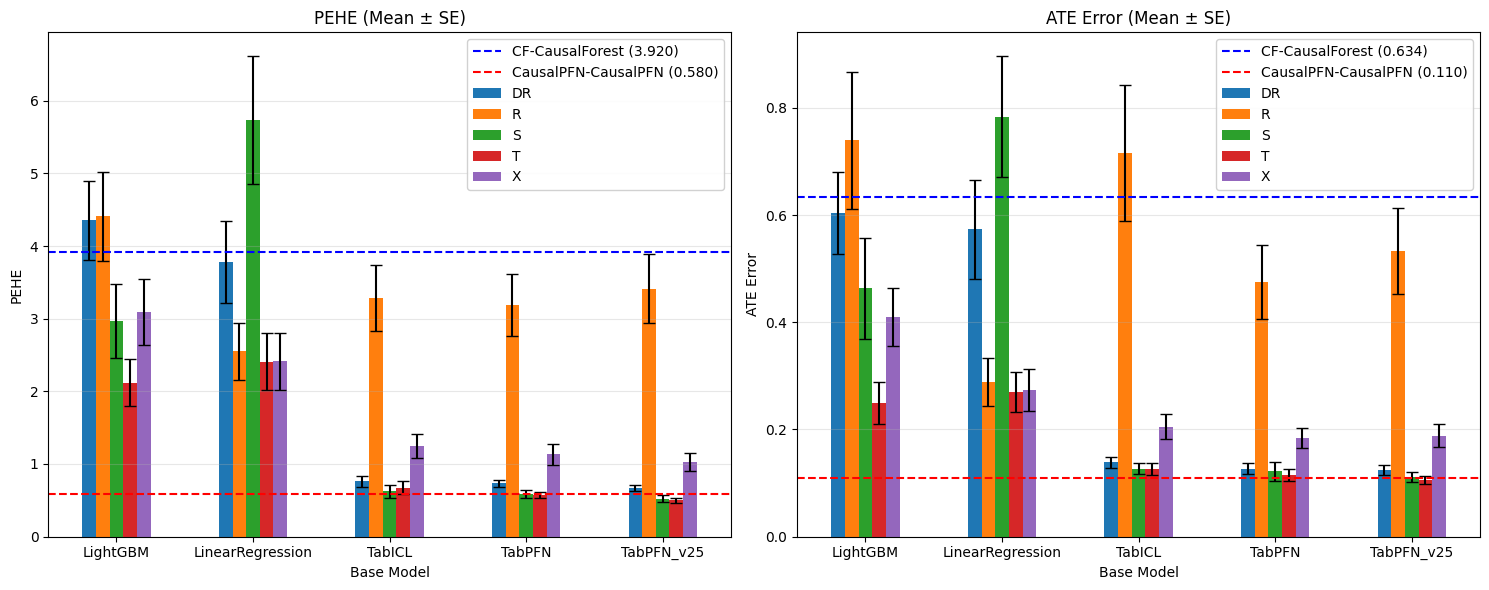

Results saved to benchmark_results_IHDP.pkl


In [30]:
# ── Results ─────────────────────────────────────────────────────────
summary_rows = []

for meta in ['S', 'T', 'X', 'R', 'DR', 'CF', 'CausalPFN']:
    if meta == 'CausalPFN':
        models = ['CausalPFN']
    elif meta == 'CF':
        models = ['CausalForest']
    else:
        base_models = ['LinearRegression', 'LightGBM', 'TabPFN', 'TabPFN_v25', 'TabICL']
        models = base_models

    for model in models:
        pehes = all_results[meta][model]['pehe']
        ate_errs = all_results[meta][model]['ate_error']

        if not pehes:
            continue

        n = len(pehes)
        summary_rows.append({
            'Meta-Learner': meta,
            'Base Model': model,
            'PEHE Mean': np.mean(pehes),
            'PEHE SE': np.std(pehes) / np.sqrt(n),
            'ATE Error Mean': np.mean(ate_errs),
            'ATE Error SE': np.std(ate_errs) / np.sqrt(n)
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Export to CSV
csv_path = 'benchmark_results_IHDP.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\nResults exported to {csv_path}")

# Visualization
if not df_summary.empty:
    df_meta = df_summary[~df_summary['Meta-Learner'].isin(['CausalPFN', 'CF'])]
    df_standalone = df_summary[df_summary['Meta-Learner'].isin(['CausalPFN', 'CF'])]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    metrics = ['PEHE', 'ATE Error']
    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        if not df_meta.empty:
            plot_data = df_meta.pivot(index='Base Model', columns='Meta-Learner', values=f'{metric} Mean')
            plot_err = df_meta.pivot(index='Base Model', columns='Meta-Learner', values=f'{metric} SE')
            plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=4, rot=0, legend=False)

        for _, row in df_standalone.iterrows():
            val = row[f'{metric} Mean']
        
            # Assign colors
            if row['Meta-Learner'] == 'CausalPFN':
                color = 'red'
            elif row['Meta-Learner'] == 'CF':
                color = 'blue'
            else:
                color = 'black'  # fallback (just in case)
        
            ax.axhline(
                y=val,
                linestyle='--',
                linewidth=1.5,
                color=color,
                label=f"{row['Meta-Learner']}-{row['Base Model']} ({val:.3f})"
            )

        ax.set_title(f'{metric} (Mean \u00b1 SE)')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.savefig("resultsihdp_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No results to plot.")

# --- Save results to disk ---
import pickle

_save_path = 'benchmark_results_IHDP.pkl'
with open(_save_path, 'wb') as f:
    pickle.dump({
        'all_results': {m: {n: dict(d) for n, d in v.items()} for m, v in all_results.items()},
        'N_ITER': N_ITER,
        'N_EST': N_EST,
        'NUISANCE_CV': NUISANCE_CV,
        'n_datasets': n_datasets,
    }, f)
print(f"Results saved to {_save_path}")

# 6. Leaderboard

In [31]:
# ── Leaderboard ─────────────────────────────────────────────────────────
# Create a ranking leaderboard for top 5 performers
print("=" * 80)
print(" " * 25 + "LEADERBOARD - TOP 5 PERFORMERS")
print("=" * 80)
print()

# Rank by PEHE (lower is better)
df_ranked_pehe = df_summary.sort_values('PEHE Mean').reset_index(drop=True)
df_ranked_pehe['Rank'] = df_ranked_pehe.index + 1

# Rank by ATE Error (lower is better)
df_ranked_ate = df_summary.sort_values('ATE Error Mean').reset_index(drop=True)
df_ranked_ate['Rank'] = df_ranked_ate.index + 1

# Display PEHE Rankings
print("PRECISION IN ESTIMATING HETEROGENEOUS EFFECTS (PEHE)")
print("   Lower is Better - Measures Individual Treatment Effect Accuracy")
print("-" * 80)
for idx, row in df_ranked_pehe.head(5).iterrows():
    rank = idx + 1
    model_name = f"{row['Meta-Learner']}-{row['Base Model']}"
    pehe_score = row['PEHE Mean']
    pehe_se = row['PEHE SE']
    
    print(f"{rank}. {model_name:30s}  PEHE: {pehe_score:6.4f} +/- {pehe_se:5.4f}")

print()
print("=" * 80)
print()

# Display ATE Error Rankings
print("AVERAGE TREATMENT EFFECT ESTIMATION (ATE Error)")
print("   Lower is Better - Measures Population-Level Treatment Effect Accuracy")
print("-" * 80)
for idx, row in df_ranked_ate.head(5).iterrows():
    rank = idx + 1
    model_name = f"{row['Meta-Learner']}-{row['Base Model']}"
    ate_score = row['ATE Error Mean']
    ate_se = row['ATE Error SE']
    
    print(f"{rank}. {model_name:30s}  ATE Error: {ate_score:6.4f} +/- {ate_se:5.4f}")

print()
print("=" * 80)
print()

# Overall winner (combining both metrics with equal weights)
# Normalize scores to 0-1 range and combine
pehe_scores = df_summary['PEHE Mean'].values
ate_scores = df_summary['ATE Error Mean'].values

pehe_normalized = (pehe_scores - pehe_scores.min()) / (pehe_scores.max() - pehe_scores.min())
ate_normalized = (ate_scores - ate_scores.min()) / (ate_scores.max() - ate_scores.min())

df_summary['Combined Score'] = (pehe_normalized + ate_normalized) / 2
df_ranked_overall = df_summary.sort_values('Combined Score').reset_index(drop=True)

print("OVERALL CHAMPION (Combined PEHE + ATE Performance)")
print("-" * 80)
winner = df_ranked_overall.iloc[0]
winner_name = f"{winner['Meta-Learner']}-{winner['Base Model']}"
print(f"Winner: {winner_name}")
print(f"   PEHE: {winner['PEHE Mean']:.4f} +/- {winner['PEHE SE']:.4f}")
print(f"   ATE Error: {winner['ATE Error Mean']:.4f} +/- {winner['ATE Error SE']:.4f}")
print()
print("=" * 80)

                         LEADERBOARD - TOP 5 PERFORMERS

PRECISION IN ESTIMATING HETEROGENEOUS EFFECTS (PEHE)
   Lower is Better - Measures Individual Treatment Effect Accuracy
--------------------------------------------------------------------------------
1. T-TabPFN_v25                    PEHE: 0.4969 +/- 0.0324
2. S-TabPFN_v25                    PEHE: 0.5224 +/- 0.0464
3. T-TabPFN                        PEHE: 0.5751 +/- 0.0399
4. CausalPFN-CausalPFN             PEHE: 0.5804 +/- 0.0699
5. S-TabPFN                        PEHE: 0.5860 +/- 0.0610


AVERAGE TREATMENT EFFECT ESTIMATION (ATE Error)
   Lower is Better - Measures Population-Level Treatment Effect Accuracy
--------------------------------------------------------------------------------
1. T-TabPFN_v25                    ATE Error: 0.1050 +/- 0.0074
2. CausalPFN-CausalPFN             ATE Error: 0.1101 +/- 0.0100
3. S-TabPFN_v25                    ATE Error: 0.1113 +/- 0.0094
4. T-TabPFN                        ATE Error: 0.115